# Assignment

## Brief

Write the Python codes for the following questions.

## Instructions

Paste the answer as Python in the answer code section below each question.

### Question 1

Question: Calculate the average no. of pizzas (count) by shop.

In [ ]:
from pyspark.sql.functions import from_json, col
from pyspark.sql.types import StringType, IntegerType, LongType, DoubleType, StructType, ArrayType, StructField

pizza_df = spark.read.format('kafka')\
    .options(**options)\
    .load()

pizza_schema = StructType([
  StructField("pizzaName", StringType()),
  StructField("additionalToppings", ArrayType(StringType())),
])

order_schema = StructType([
  StructField("address", StringType()),
  StructField("id", IntegerType()),
  StructField("name", StringType()),
  StructField("phoneNumber", StringType()),
  StructField("shop", StringType()),
  StructField("cost", DoubleType()),
  StructField("pizzas", ArrayType(pizza_schema)),
  StructField("timestamp", LongType()),
])

parsed_df = pizza_df.select("timestamp", from_json(col("value").cast("string"), order_schema).alias("value"))

Answer:

In [ ]:
# Assignment
# This exercise assumed has run the 3 notebooks in this lessons.
# sum() and avg() only work on numbers, but value.pizzas contains a list of pizza objects for each order.
# Spark cannot directly add or average arrays.
# First convert the array into a numeric count using size(), then aggregate that count.

from pyspark.sql.functions import size, col, avg

parsed_df.select(
    col("value.shop").alias("shop"),
    size(col("value.pizzas")).alias("pizza_count")
).groupBy("shop").agg(
    avg("pizza_count").alias("avg_pizza_count")
).show(truncate=False)

## Output
### This exercise assumed has run the 3 notebooks in this lessons.

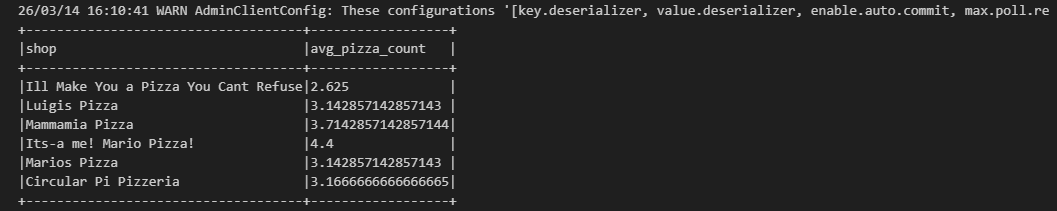

## Submission

- Submit the URL of the GitHub Repository that contains your work to NTU black board.
- Should you reference the work of your classmate(s) or online resources, give them credit by adding either the name of your classmate or URL.